# Week5

### info
```
Shreyas Nayak
240911006
Week 5 
dataset : random_college_gpa_data.xlsx
```

# Task1

DAML Final Task 1

Apply all the learnings of Eda and visualisation on random_college_gpa_data and derive conclusions and corrections.

It's open to your interpretation and files with best applications of the topics and neat and insightful code will get a score out of 25 points.

Deadline: 11:59 pm, 31st July 

Submit here: https://forms.gle/iHhscLhboDH3uigD7

## Importing and datasets info

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_excel("random_college_gpa_data.xlsx")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7094 entries, 0 to 7093
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Section          7094 non-null   object 
 1   Course Code      7094 non-null   int64  
 2   Course Name      7094 non-null   object 
 3   Semester         7094 non-null   object 
 4   Lateral Student  7094 non-null   object 
 5   Department Code  7094 non-null   object 
 6   CGPA             7094 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 388.1+ KB


In [8]:
df.isnull().sum()


Section            0
Course Code        0
Course Name        0
Semester           0
Lateral Student    0
Department Code    0
CGPA               0
dtype: int64

In [33]:
df.describe()

,Course Code,CGPA
count,7094.000000,7094.000000
mean,928.447420,7.185337
std,23.881498,1.384812
min,902.000000,0.000000
25%,907.000000,6.430000
50%,924.000000,7.310000
75%,953.000000,8.150000
max,968.000000,10.000000


## Data Visualisation

## Total NO of Studs

In [36]:
total_students = len(df)
print(f"Total number of students: {total_students}")


Total number of students: 7094


## Number of Students in Each Sem

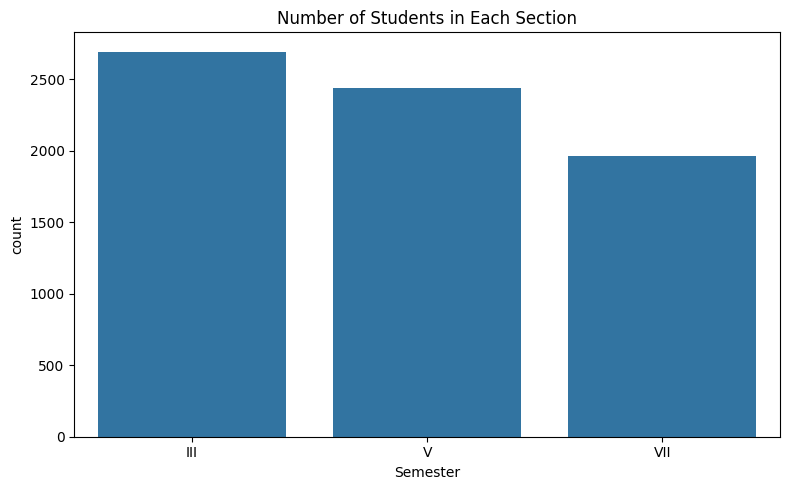

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Semester')
plt.title('Number of Students in Each Section')
plt.tight_layout()
plt.show()

### CGPA vs Sem

Average CGPA per Semester:
   Semester      CGPA
0      III  7.210587
1        V  7.140419
2      VII  7.206451


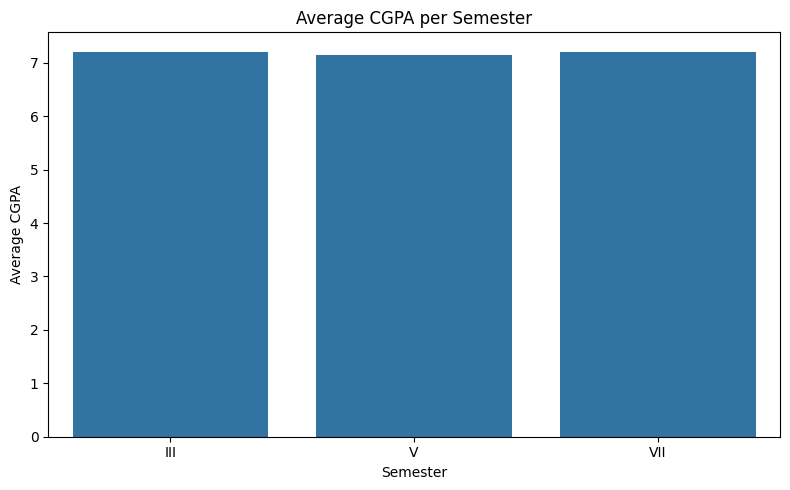

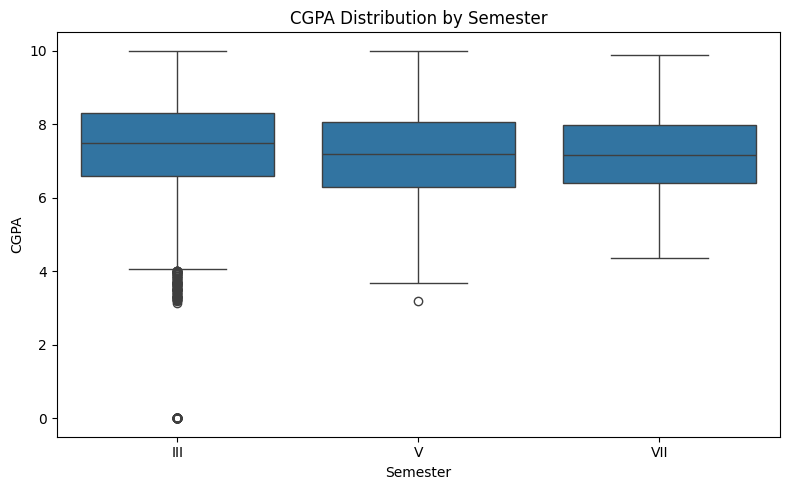

In [16]:
semester_cgpa = df.groupby('Semester')['CGPA'].mean().reset_index()
print("Average CGPA per Semester:\n", semester_cgpa)


plt.figure(figsize=(8, 5))
sns.barplot(data=semester_cgpa, x='Semester', y='CGPA')
plt.title('Average CGPA per Semester')
plt.ylabel('Average CGPA')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Semester', y='CGPA')
plt.title('CGPA Distribution by Semester')
plt.tight_layout()
plt.show()


## CGPA each Sec Of Each Sem

In [20]:
sem_section_cgpa = df.groupby(['Semester', 'Section'])['CGPA'].mean().reset_index()
print("Average CGPA per Semester and Section:\n", sem_section_cgpa.head())

Average CGPA per Semester and Section:
   Semester Section      CGPA
0      III       A  7.023370
1      III       B  7.267752
2      III       C  7.391852
3      III       D  7.581480
4        V       A  7.113711


## CGPA with/without Lateral Study

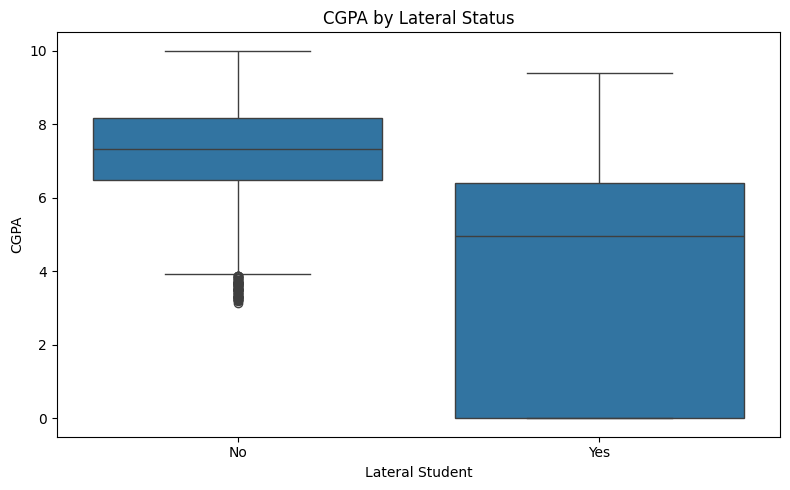

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Lateral Student', y='CGPA')
plt.title('CGPA by Lateral Status')
plt.tight_layout()
plt.show()

## People in each lateral study

In [39]:
lateral_counts = df['Lateral Student'].value_counts()
print("Student Count by Lateral Status:\n", lateral_counts)

Student Count by Lateral Status:
 Lateral Student
No     6952
Yes     142
Name: count, dtype: int64


## CPGA Relative to the depertment 

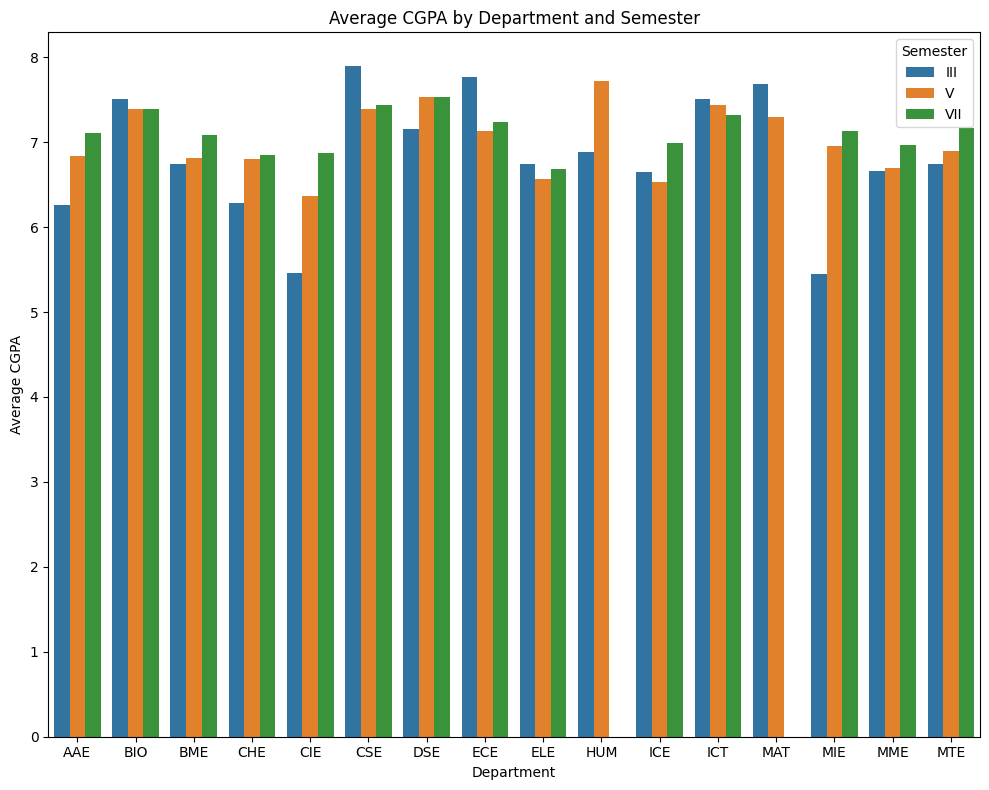

In [27]:
sem_dept_cgpa = df.groupby(['Semester', 'Department Code'])['CGPA'].mean().reset_index()
#print(sem_dept_cgpa.head())
plt.figure(figsize=(10,8))
sns.barplot(data=sem_dept_cgpa,x='Department Code',y='CGPA',hue='Semester')
plt.title('Average CGPA by Department and Semester')
plt.xlabel('Department')
plt.ylabel('Average CGPA')
plt.tight_layout()
plt.show()


## Student Count in each Section

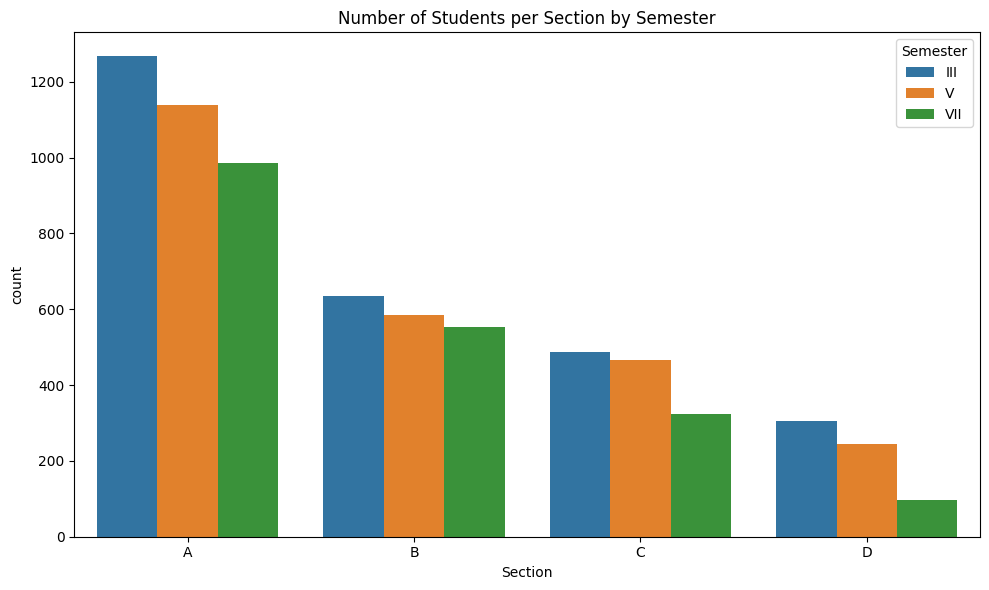

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Section', hue='Semester')
plt.title('Number of Students per Section by Semester')
plt.tight_layout()
plt.show()


## CGPA Voilin with sem and lateral entry

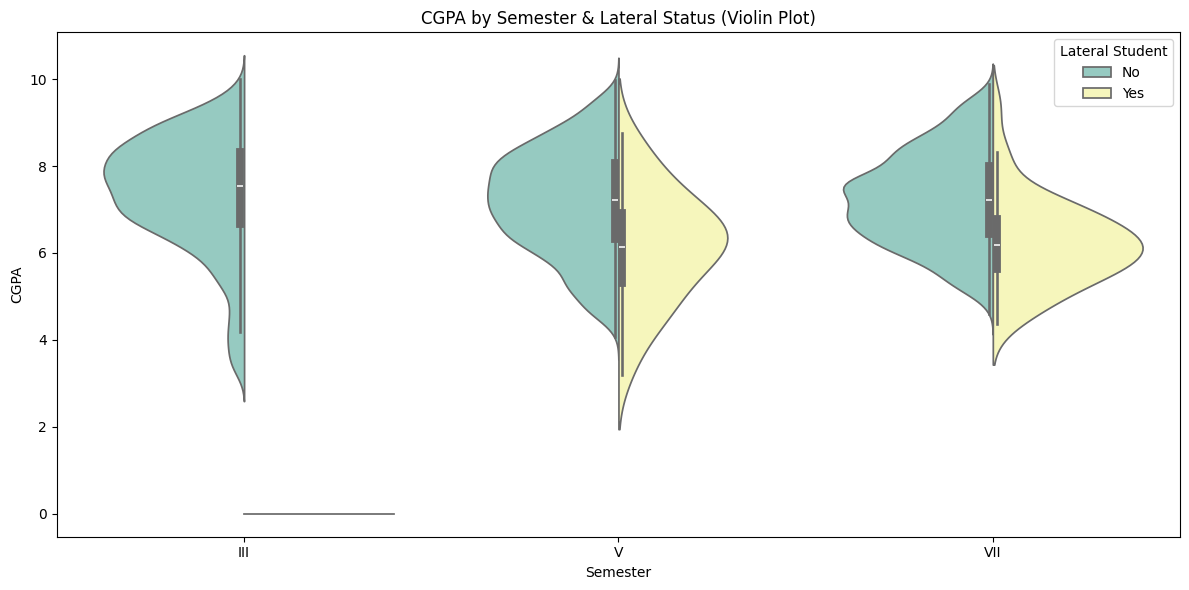

In [42]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Semester', y='CGPA', hue='Lateral Student', split=True, palette='Set3')
plt.title('CGPA by Semester & Lateral Status (Violin Plot)')
plt.xlabel('Semester')
plt.ylabel('CGPA')
plt.tight_layout()
plt.show()


# Task2

*DAML Final Task 2*

Apply all the learnings of Machine Learning so far and use  weather data to train a model, and use it to predict *latitude, longitude and condition_text*, for weather_test_150 dataset.

You need to submit the weather_test_150 file along with the target columns as well as your notebook.

It's open to your interpretation and files with best applications of the topics and neat and insightful code *along with the most accuracy* will get a score out of 25 points.

Deadline: 11:59 pm, 31st July 

Submit here: https://forms.gle/J83fgEdfAxjRpipx9

## Importing and dataset making

In [99]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, classification_report
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [100]:
train_df = pd.read_excel("weather.xlsx")
test_df = pd.read_excel("weather_test_150.xlsx")

In [101]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84614 entries, 0 to 84613
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       84614 non-null  object        
 1   location_name                 84613 non-null  object        
 2   latitude                      84614 non-null  float64       
 3   longitude                     84614 non-null  float64       
 4   timezone                      84614 non-null  object        
 5   last_updated_epoch            84614 non-null  int64         
 6   last_updated                  84614 non-null  datetime64[ns]
 7   temperature_celsius           84614 non-null  float64       
 8   temperature_fahrenheit        84614 non-null  float64       
 9   condition_text                84614 non-null  object        
 10  wind_mph                      84614 non-null  float64       
 11  wind_kph                    

In [102]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       150 non-null    object        
 1   location_name                 150 non-null    object        
 2   timezone                      150 non-null    object        
 3   last_updated_epoch            150 non-null    int64         
 4   last_updated                  150 non-null    datetime64[ns]
 5   temperature_celsius           150 non-null    float64       
 6   temperature_fahrenheit        150 non-null    float64       
 7   wind_mph                      150 non-null    float64       
 8   wind_kph                      150 non-null    float64       
 9   wind_degree                   150 non-null    int64         
 10  wind_direction                150 non-null    object        
 11  pressure_mb                   15

## Dropping unwanted attributes

In [123]:
drop_cols = [
    'country', 'location_name', 'timezone', 'last_updated', 'last_updated_epoch', 
    'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase'
]


targets = ['latitude', 'longitude', 'condition_text']

## Making Traing and Testing datasets

In [124]:
X = train_df.drop(columns=drop_cols + targets, errors='ignore')
y_lat = train_df['latitude']
y_long = train_df['longitude']
y_cond = train_df['condition_text']
X_test = test_df.drop(columns=drop_cols, errors='ignore')

In [125]:
categorical_cols = X.select_dtypes(include='object').columns
encoders = {}

In [126]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str)) 

## Standerization

In [127]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

In [128]:
lat_model = LinearRegression()
lat_model.fit(X_scaled, y_lat)
pred_lat = lat_model.predict(X_test_scaled)

long_model = LinearRegression()
long_model.fit(X_scaled, y_long)
pred_long = long_model.predict(X_test_scaled)

In [129]:
le_cond = LabelEncoder()
y_cond_encoded = le_cond.fit_transform(y_cond)

In [130]:
lat_model = LinearRegression()
long_model = LinearRegression()

lat_model.fit(X_scaled, y_lat)
long_model.fit(X_scaled, y_long)

LinearRegression()

In [131]:
pred_lat = lat_model.predict(X_test_scaled)
pred_long = long_model.predict(X_test_scaled)

In [135]:
X_train_cond, X_val_cond, y_train_cond, y_val_cond = train_test_split(X_scaled, y_cond_encoded, test_size=0.2, random_state=42)

In [143]:
val_preds_encoded = cond_model.predict(X_val_cond)
print("Condition Accuracy on Validation Set:", accuracy_score(y_val_cond, val_preds_encoded))

Condition Accuracy on Validation Set: 0.688175855344797


In [144]:
pred_cond_encoded = cond_model.predict(X_test_scaled)
pred_cond = le_cond.inverse_transform(pred_cond_encoded)

## Saving the model

In [145]:
test_output = pd.DataFrame({
    'latitude': pred_lat,
    'longitude': pred_long,
})

test_output[['latitude', 'longitude']].to_csv("weather_test_150_predictions.csv", index=False)
print("Predictions saved to weather_test_150_predictions.csv")


# Combine all predictions into a DataFrame
test_output = pd.DataFrame({
    'latitude': pred_lat,
    'longitude': pred_long,
    'condition_text': pred_cond
})

# Save to CSV
test_output.to_csv("weather_test_150_predictions.csv", index=False)

print("✅ Submission file saved as 'weather_test_150_predictions.csv'")


Predictions saved to weather_test_150_predictions.csv
✅ Submission file saved as 'weather_test_150_predictions.csv'


## Accuracy

In [146]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val_cond,
    val_preds_encoded,
    labels=le_cond.transform(le_cond.classes_),
    target_names=le_cond.classes_,
    zero_division=0  
))


                                             precision    recall  f1-score   support

                                   Blizzard       0.00      0.00      0.00         1
                               Blowing snow       0.00      0.00      0.00         5
                                      Clear       0.68      0.62      0.65       729
                                     Cloudy       0.00      0.00      0.00       154
                                        Fog       0.71      0.76      0.73       155
                           Freezing drizzle       0.00      0.00      0.00         0
                               Freezing fog       0.67      0.22      0.33         9
                                 Heavy rain       0.40      0.25      0.31         8
                        Heavy rain at times       0.00      0.00      0.00         2
                                 Heavy snow       0.59      0.67      0.62        15
                              Light drizzle       0.47      0.21

In [147]:
accuracy = accuracy_score(y_val, y_pred)
print(f"Condition Text Accuracy: {accuracy:.4f}")


Condition Text Accuracy: 0.6882


# Thank yOU